Kacper Kaszuba

### PySpark Otomoto Demo

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023


In [ ]:
import os
# os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
# Pracoje w Colab a więc nie musze ustawiać JAVA_HOME

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import  StringType, IntegerType
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [ ]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [ ]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/content/otomoto_offers_eng_23-04-2023.csv. SQLSTATE: 42K03

**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [ ]:
df.show()

26/05/16 01:57:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [ ]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [ ]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [ ]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [ ]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka


+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [ ]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [ ]:
df.createOrReplaceTempView("cars")

In [ ]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [ ]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [ ]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [ ]:
# zależność ceny od przebiegu
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


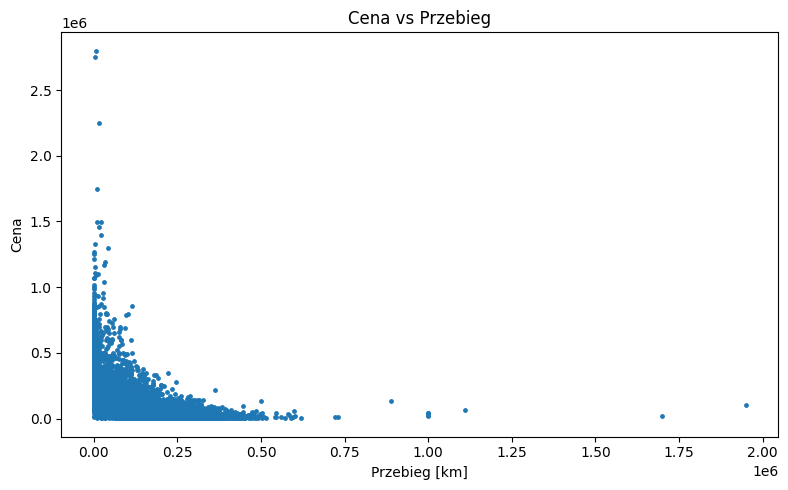

In [ ]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [ ]:
spark = SparkSession.builder \
    .appName("Crime") \
    .getOrCreate()


In [ ]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
df_crimes = spark.read.option("header", True).option("quote", '"').csv("chicago_crimes_sample.csv")
df_crimes.show(10)


+-------------+----------------+--------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------+
|           id|     case_number|                date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|          updated_on|    latitude|    longitude|location|
+-------------+----------------+--------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------+
|     14193193|        JK249780|2026-05-07T00:00:...|057XX S MASSASOIT...|0820|       THEFT|      $500 AND UNDER|              STREET| false|   false|0811

In [ ]:
df_crimes.describe()

DataFrame[summary: string, id: string, case_number: string, date: string, block: string, iucr: string, primary_type: string, description: string, location_description: string, arrest: string, domestic: string, beat: string, district: string, ward: string, community_area: string, fbi_code: string, x_coordinate: string, y_coordinate: string, year: string, updated_on: string, latitude: string, longitude: string, location: string]

### Wyjaśnienie funkcji czyszczących w Twoim kodzie:

| Funkcja | Działanie |
| :--- | :--- |
| `withColumn` | Tworzy nową kolumnę w zbiorze danych. |
| `regexp_replace(col, r"[^\d]", "")` | Usuwa z tekstu wszystko, co nie jest cyfrą (regex `[^\d]` szuka znaków niebędących liczbami). |
| `cast("type")` | Zmienia typ danych (np. ze String na Double/Integer), co umożliwia obliczenia matematyczne. |
| `trim` | Usuwa białe znaki (spacje, tabulatory) z początku i końca tekstu. |
| `lower` | Zamienia wszystkie litery na małe (standaryzacja kategorii). |

### Typowe metody czyszczenia danych w PySpark:

1. **Usuwanie duplikatów**: `df.dropDuplicates()`
2. **Obsługa braków (NULL)**: `df.dropna()` (usuwanie) lub `df.fillna(0)` (uzupełnianie).
3. **Filtrowanie**: `df.filter(condition)` do usuwania błędnych lub odstających rekordów.
4. **Typowanie danych**: Zawsze warto upewnić się, że daty to `DateType`, a liczby to `NumericType` używając `.cast()`.

In [ ]:
df_crimes = df_crimes.dropna(subset=['id', 'case_number', 'date', 'block', 'primary_type', 'latitude', 'longitude'])
df_crimes = df_crimes.fillna('BRAK DANYCH', subset=['location_description', 'description'])


In [ ]:
df_crimes.show(5)

+--------+-----------+--------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------+
|      id|case_number|                date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|          updated_on|    latitude|    longitude|location|
+--------+-----------+--------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------+
|14193193|   JK249780|2026-05-07T00:00:...|057XX S MASSASOIT...|0820|       THEFT|      $500 AND UNDER|              STREET| false|   false|0811|     008|  13|            56|      06| 

In [ ]:
df_crimes.printSchema()

root
 |-- id: string (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: string (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: string (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = false)
 |-- location_description: string (nullable = false)
 |-- arrest: string (nullable = true)
 |-- domestic: string (nullable = true)
 |-- beat: string (nullable = true)
 |-- district: string (nullable = true)
 |-- ward: string (nullable = true)
 |-- community_area: string (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: string (nullable = true)
 |-- y_coordinate: string (nullable = true)
 |-- year: string (nullable = true)
 |-- updated_on: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- location: string (nullable = true)



Co zmienić na co
- id - int
- case_number - str
- date - date time
- block - string
- iucr - int
- primary_type - str
- description - str
- location_description - str
- arrest - bool
- domestic - bool
- beat - int
- district - int
- ward - int
- comunity_area - int
- fbi_code - int
- x_cord - int
- y_cord - int
- year - date(sam rok) or int
- upadted_on - date time
- latitude - float
- longitude - float
- location - ?

In [ ]:
records_with_time = df_crimes.filter(F.hour(F.col("date")) > 0).count()

print(f"Liczba rekordów z godziną inną niż północ: {records_with_time}")

Liczba rekordów z godziną inną niż północ: 47039


Przeprowadziłem test aby sprawdizć czy jest jakas inna godzina niż 00:00 (jeżeli nie to dałbym samo date)

ale są różne a więc zostawiamy datetime

In [ ]:
df_crimes = df_crimes.withColumn("ID",
                   F.regexp_replace(F.col("id"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("date",
                   F.to_timestamp(F.col("date")))

text_cols = ["block", "primary_type", "description", "location_description"]

for col_name in text_cols:
    df_crimes = df_crimes.withColumn(col_name, F.upper(F.trim(F.col(col_name))))

df_crimes = df_crimes.withColumn("iucr",
                   F.regexp_replace(F.col("iucr"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("arrest",
                   F.lower(F.trim(F.col("arrest"))).cast("boolean"))

df_crimes = df_crimes.withColumn("domestic",
                   F.lower(F.trim(F.col("domestic"))).cast("boolean"))


df_crimes = df_crimes.withColumn("beat",
                   F.regexp_replace(F.col("beat"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("district",
                   F.regexp_replace(F.col("district"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("ward",
                   F.regexp_replace(F.col("ward"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("community_area",
                   F.regexp_replace(F.col("community_area"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("fbi_code",
                   F.trim(F.col("fbi_code")))


df_crimes = df_crimes.withColumn("x_coordinate",
                   F.trim(F.col("x_coordinate")).cast("integer"))

df_crimes = df_crimes.withColumn("y_coordinate",
                   F.regexp_replace(F.col("y_coordinate"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("year",
                   F.regexp_replace(F.col("year"), r"[^\d]", "").cast("integer"))

df_crimes = df_crimes.withColumn("updated_on",
                   F.to_timestamp(F.col("updated_on")))


df_crimes = df_crimes.withColumn("latitude",
                   F.trim(F.col("latitude")).cast("double"))

df_crimes = df_crimes.withColumn("longitude",
                   F.trim(F.col("longitude")).cast("double"))

df_crimes = df_crimes.withColumn("location", F.regexp_replace(F.col("location"), r'[\"()]', ""))

In [ ]:
df_crimes.show(5)

+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|      ID|case_number|               date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|
+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+
|14193193|   JK249780|2026-05-07 00:00:00|057XX S MASSASOIT...| 820|       THEFT|      $500 AND UNDER|              STREET| false|   false| 811|       8|  13|            56|      06|     113

In [ ]:
df_crimes.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- case_number: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- block: string (nullable = true)
 |-- iucr: integer (nullable = true)
 |-- primary_type: string (nullable = true)
 |-- description: string (nullable = false)
 |-- location_description: string (nullable = false)
 |-- arrest: boolean (nullable = true)
 |-- domestic: boolean (nullable = true)
 |-- beat: integer (nullable = true)
 |-- district: integer (nullable = true)
 |-- ward: integer (nullable = true)
 |-- community_area: integer (nullable = true)
 |-- fbi_code: string (nullable = true)
 |-- x_coordinate: integer (nullable = true)
 |-- y_coordinate: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- updated_on: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- location: string (nullable = true)



In [ ]:
df_crimes.dtypes

[('ID', 'int'),
 ('case_number', 'string'),
 ('date', 'timestamp'),
 ('block', 'string'),
 ('iucr', 'int'),
 ('primary_type', 'string'),
 ('description', 'string'),
 ('location_description', 'string'),
 ('arrest', 'boolean'),
 ('domestic', 'boolean'),
 ('beat', 'int'),
 ('district', 'int'),
 ('ward', 'int'),
 ('community_area', 'int'),
 ('fbi_code', 'string'),
 ('x_coordinate', 'int'),
 ('y_coordinate', 'int'),
 ('year', 'int'),
 ('updated_on', 'timestamp'),
 ('latitude', 'double'),
 ('longitude', 'double'),
 ('location', 'string')]

In [ ]:
# Etap 2
# rano 6-9 przedpołudnie 9-12  południe 12 popoludnie 13-17 wieczor 17-21 noc 21-5
def time_of_day(hour):

  match hour:
    case hour if hour in range(6, 9):
      return "Rano"
    case hour if hour in range(9, 12):
      return "Przedpołudnie"
    case hour if hour == 12:
      return "Południe"
    case hour if hour in range(13, 17):
      return "Popołudnie"
    case hour if hour in range(17, 21):
      return "Wieczór"
    case hour if hour in range(21, 23+1) or hour in range(1, 6):
      return "Noc"
    case _:
      return "Północ"


In [ ]:
udf_pora_dnia = F.udf(time_of_day, StringType())
df_crimes = df_crimes.withColumn("pora_dnia", udf_pora_dnia(F.hour(F.col('date'))))
df_crimes.show(10)

+--------+-----------+-------------------+--------------------+----+-------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+---------+
|      ID|case_number|               date|               block|iucr| primary_type|         description|location_description|arrest|domestic|beat|district|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|pora_dnia|
+--------+-----------+-------------------+--------------------+----+-------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+---------+
|14193193|   JK249780|2026-05-07 00:00:00|057XX S MASSASOIT...| 820|        THEFT|      $500 AND UNDER|              STREET| false|   false| 811|       8|  1

In [ ]:
district_name = spark.createDataFrame([
    (1, 'Central'),
    (2, 'Wentworth'),
    (3, 'Grand Crossing'),
    (4, 'South Chicago'),
    (5, 'Calumet'),
    (6, 'Gresham'),
    (7, 'Englewood'),
    (8, 'Chicago Lawn'),
    (9, 'Deering'),
    (10, 'Ogden'),
    (11, 'Harrison'),
    (12, 'Near West'),
    (14, 'Shakespeare'),
    (15, 'Austin'),
    (16, 'Jefferson Park'),
    (17, 'Albany Park'),
    (18, 'Near North'),
    (19, 'Town Hall'),
    (20, 'Lincoln'),
    (22, 'Morgan Park'),
    (24, 'Rogers Park'),
    (25, 'Grand Central')],
    ["district", "district_name"])

df_crimes = df_crimes.join(F.broadcast(district_name), on="district", how='left')
df_crimes.show(5)

+--------+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+---------+--------------+
|district|      ID|case_number|               date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|pora_dnia| district_name|
+--------+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+---------+--------------+
|       8|14193193|   JK249780|2026-05-07 00:00:00|057XX S MASSASOIT...| 820|       THEFT|      $500 AND UNDER|    

In [ ]:
df_crimes.cache()
df_crimes.write.mode("overwrite").partitionBy("year").parquet("chicago_crimes_parquet")

In [ ]:
# ze względu na pore dnia
most_comon_crime = df_crimes.groupBy("primary_type", "pora_dnia").count().orderBy(F.desc("count"))
most_comon_crime.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#1687L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(count#1687L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=371]
      +- HashAggregate(keys=[primary_type#764, pora_dnia#872], functions=[count(1)])
         +- Exchange hashpartitioning(primary_type#764, pora_dnia#872, 200), ENSURE_REQUIREMENTS, [plan_id=368]
            +- HashAggregate(keys=[primary_type#764, pora_dnia#872], functions=[partial_count(1)])
               +- InMemoryTableScan [primary_type#764, pora_dnia#872]
                     +- InMemoryRelation [district#771, ID#761, case_number#18, date#762, block#763, iucr#767, primary_type#764, description#765, location_description#766, arrest#768, domestic#769, beat#770, ward#772, community_area#773, fbi_code#774, x_coordinate#775, y_coordinate#776, year#777, updated_on#778, latitude#779, longitude#780, location#781, pora_dnia#872, district_name#967], StorageLevel(disk, memory, deseriali

In [ ]:
most_comon_crime.show()

+-------------------+-------------+-----+
|       primary_type|    pora_dnia|count|
+-------------------+-------------+-----+
|              THEFT|   Popołudnie| 2877|
|            BATTERY|          Noc| 2735|
|              THEFT|      Wieczór| 2330|
|    CRIMINAL DAMAGE|          Noc| 1984|
|            BATTERY|      Wieczór| 1961|
|              THEFT|          Noc| 1913|
|            BATTERY|   Popołudnie| 1856|
|              THEFT|Przedpołudnie| 1642|
|MOTOR VEHICLE THEFT|          Noc| 1342|
|            ASSAULT|   Popołudnie| 1125|
|            BATTERY|Przedpołudnie| 1086|
|           BURGLARY|          Noc| 1071|
|    CRIMINAL DAMAGE|      Wieczór| 1015|
|            ASSAULT|      Wieczór|  988|
|MOTOR VEHICLE THEFT|      Wieczór|  925|
|              THEFT|         Rano|  912|
|            ASSAULT|          Noc|  876|
|    CRIMINAL DAMAGE|   Popołudnie|  842|
|              THEFT|     Południe|  755|
|      OTHER OFFENSE|      Wieczór|  752|
+-------------------+-------------

In [ ]:
# ze względu na dystrykt
most_comon_crime_dsc = df_crimes.groupBy("primary_type", "district_name").count().orderBy(F.desc("count"))
most_comon_crime_dsc.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#2685L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(count#2685L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=456]
      +- HashAggregate(keys=[primary_type#764, district_name#967], functions=[count(1)])
         +- Exchange hashpartitioning(primary_type#764, district_name#967, 200), ENSURE_REQUIREMENTS, [plan_id=453]
            +- HashAggregate(keys=[primary_type#764, district_name#967], functions=[partial_count(1)])
               +- InMemoryTableScan [primary_type#764, district_name#967]
                     +- InMemoryRelation [district#771, ID#761, case_number#18, date#762, block#763, iucr#767, primary_type#764, description#765, location_description#766, arrest#768, domestic#769, beat#770, ward#772, community_area#773, fbi_code#774, x_coordinate#775, y_coordinate#776, year#777, updated_on#778, latitude#779, longitude#780, location#781, pora_dnia#872, district_name#967], StorageLevel(disk, m

In [ ]:
most_comon_crime_dsc.show()

+------------+--------------+-----+
|primary_type| district_name|count|
+------------+--------------+-----+
|       THEFT|     Town Hall| 1135|
|       THEFT|    Near North| 1031|
|       THEFT|       Central|  883|
|       THEFT|     Near West|  833|
|       THEFT|  Chicago Lawn|  654|
|     BATTERY|Grand Crossing|  623|
|     BATTERY|       Gresham|  613|
|     BATTERY|  Chicago Lawn|  577|
|       THEFT|     Wentworth|  549|
|     BATTERY| South Chicago|  539|
|     BATTERY|      Harrison|  513|
|       THEFT|       Deering|  506|
|     BATTERY|     Wentworth|  502|
|       THEFT|   Shakespeare|  502|
|     BATTERY|     Englewood|  491|
|     BATTERY|         Ogden|  486|
|     BATTERY|     Near West|  471|
|       THEFT| Grand Central|  457|
|       THEFT|Grand Crossing|  456|
|     BATTERY| Grand Central|  452|
+------------+--------------+-----+
only showing top 20 rows


In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
# etap 5
# StringIndexer
# VectorAssembler


# Obecnie arrest i domestic to bool a StringIndexer ic hnei boslogoje więc zaminaimy je na 0 i 1

df_crimes = df_crimes.withColumn("arrest_index", F.col("arrest").cast("double"))
df_crimes = df_crimes.withColumn("domestic_index", F.col("domestic").cast("double"))

stringIndexer = StringIndexer(inputCols=["primary_type", "pora_dnia", "district", "location_description"], outputCols=["label", "pora_dnia_index", "district_index", "location_index"])
model_crimes = stringIndexer.fit(df_crimes).transform(df_crimes)

model_crimes.show(5)

+--------+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+---------+--------------+------------+--------------+-----+---------------+--------------+--------------+
|district|      ID|case_number|               date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|pora_dnia| district_name|arrest_index|domestic_index|label|pora_dnia_index|district_index|location_index|
+--------+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+----

In [ ]:
assembler = VectorAssembler(inputCols=["domestic_index", "arrest_index", "pora_dnia_index", "district_index", "location_index", "latitude", "longitude"], outputCol="features")
model_crimes = assembler.transform(model_crimes)
model_crimes.show(5)

+--------+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+---------+--------------+------------+--------------+-----+---------------+--------------+--------------+--------------------+
|district|      ID|case_number|               date|               block|iucr|primary_type|         description|location_description|arrest|domestic|beat|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location|pora_dnia| district_name|arrest_index|domestic_index|label|pora_dnia_index|district_index|location_index|            features|
+--------+--------+-----------+-------------------+--------------------+----+------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+

Dodatek:

W 4 rzędzie mamy takie coś `(7,[2,5,6],[5.0,4...`
Nie jest to błąd a zmniejszanie obciążenia RAM przez pysparka. Prawdopodobnie w tym rzędzie jest bardzo dużo 0, Spark więc kompresuje ten wektor. Mówi nam że w większości są to wartości 0 a wartości nie zerowe znajdują sie na pozycjach: `2, 5 i 6` a wynoszą odpowiednio `5.0, 4...` no nie widać więcej ale wiemy o co chodzi.

In [ ]:
train_data, test_data = model_crimes.randomSplit(weights=[0.8, 0.2], seed = 42)

In [ ]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol='label',
    maxBins=150,
    numTrees=100,
    maxDepth=12,
    seed=42
)
trained_model_rf = rf.fit(train_data)
predictions_rf = trained_model_rf.transform(test_data)
predictions_rf.show(5)

+--------+--------+-----------+-------------------+--------------------+----+-----------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+----------+-------------+------------+--------------+-----+---------------+--------------+--------------+--------------------+--------------------+--------------------+----------+
|district|      ID|case_number|               date|               block|iucr|     primary_type|         description|location_description|arrest|domestic|beat|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location| pora_dnia|district_name|arrest_index|domestic_index|label|pora_dnia_index|district_index|location_index|            features|       rawPrediction|         probability|prediction|
+--------+--------+-----------+-------------------+--------------------+----+---------------

In [ ]:
# IndexToString
old_labels = predictions_rf.schema["label"].metadata["ml_attr"]["vals"]
konwerter = IndexToString(inputCol="prediction", outputCol='predicted_crime', labels=old_labels)
real_prediction = konwerter.transform(predictions_rf)
real_prediction.select(['primary_type', 'predicted_crime', 'probability']).show(20, truncate=False)

+-------------------+-------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|primary_type       |predicted_crime    |probability                                                                                                                                                                                                                                                                                                                                       

In [ ]:
# acc
ewaluator = MulticlassClassificationEvaluator(labelCol = "label", predictionCol='prediction', metricName="accuracy")
accuracy = ewaluator.evaluate(predictions_rf)
print(f"Accuracy modelu wynosi: {accuracy}")


Accuracy modelu wynosi: 0.3931537370873


In [ ]:
semi_matrix = real_prediction.groupBy("primary_type").pivot("predicted_crime").count().fillna(0)
semi_matrix.show()

+--------------------+-------+-------+--------+---------------------------------+---------------+-----------------------+-----------------+------------------+--------+--------------------+-------------------+---------+-------------+------------+-------+-----+-----------------+
|        primary_type|ASSAULT|BATTERY|BURGLARY|CONCEALED CARRY LICENSE VIOLATION|CRIMINAL DAMAGE|CRIMINAL SEXUAL ASSAULT|CRIMINAL TRESPASS|DECEPTIVE PRACTICE|HOMICIDE|LIQUOR LAW VIOLATION|MOTOR VEHICLE THEFT|NARCOTICS|OTHER OFFENSE|PROSTITUTION|ROBBERY|THEFT|WEAPONS VIOLATION|
+--------------------+-------+-------+--------+---------------------------------+---------------+-----------------------+-----------------+------------------+--------+--------------------+-------------------+---------+-------------+------------+-------+-----+-----------------+
|OFFENSE INVOLVING...|      0|     62|       1|                                0|              1|                      0|                1|                 4|       0

In [ ]:
# Wykresy
import matplotlib.pyplot as plt
import seaborn as sns

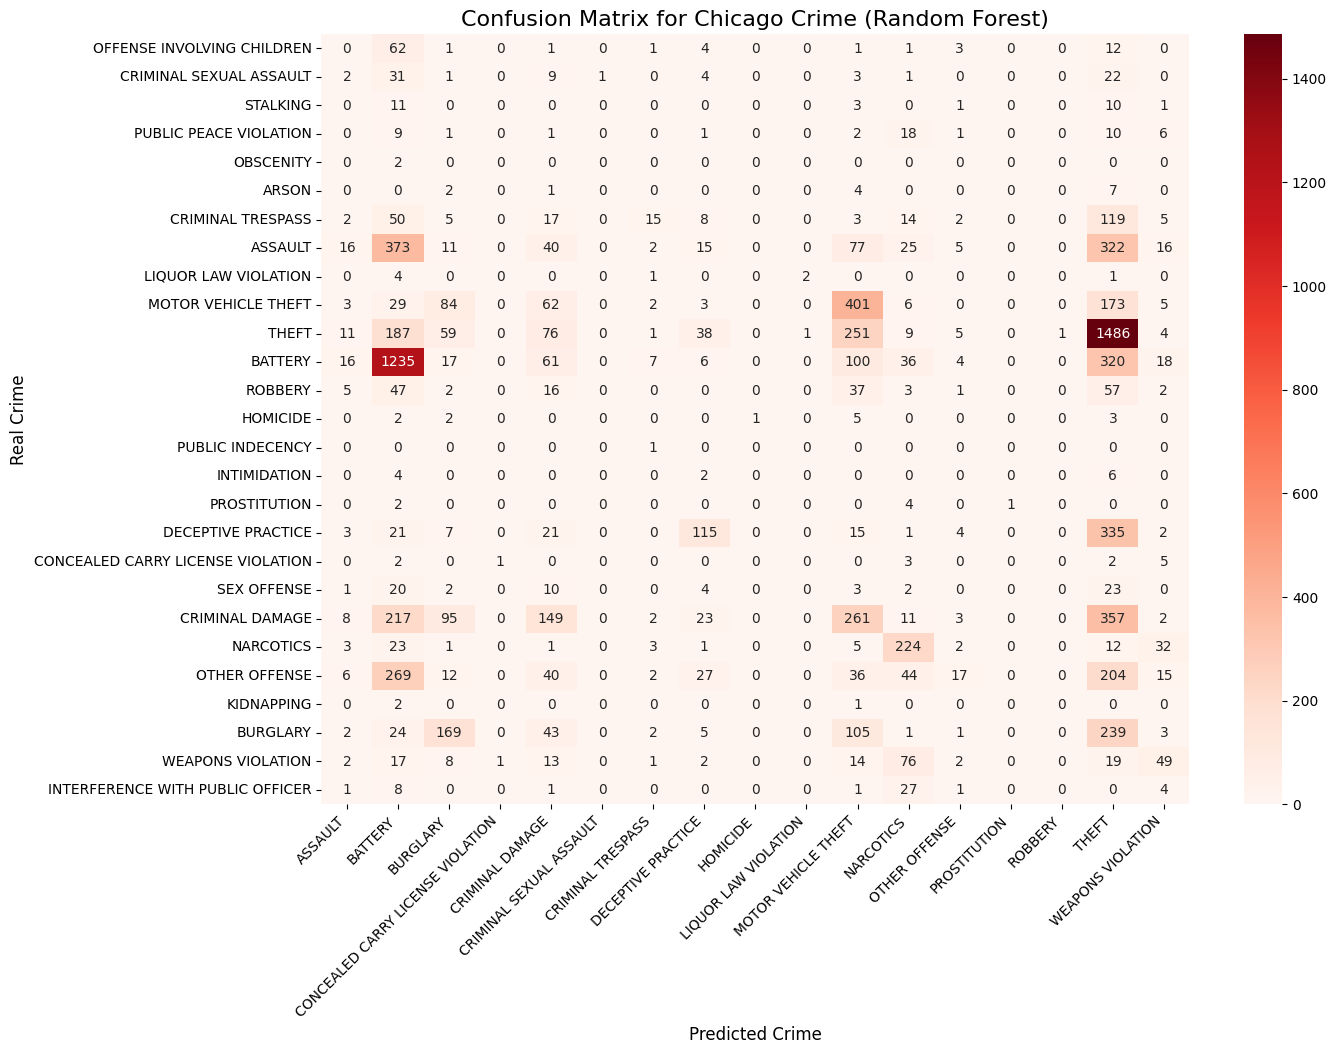

In [ ]:
matrix_crime = semi_matrix.toPandas()
matrix_crime.set_index('primary_type', inplace=True)

plt.figure(figsize=(14, 10))
sns.heatmap(matrix_crime, annot=True, fmt='g', cmap='Reds')

plt.title('Confusion Matrix for Chicago Crime (Random Forest)', fontsize=16)
plt.ylabel("Real Crime", fontsize=12)
plt.xlabel("Predicted Crime", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
import pandas as pd

/tmp/ipykernel_15704/2009880253.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Ważność", y="Cecha", data=df_waznosc, palette='viridis')


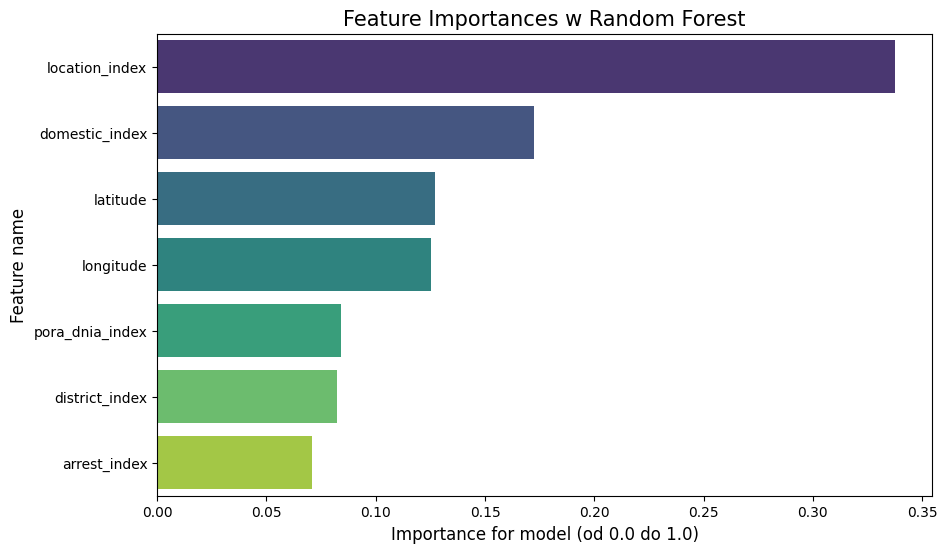

In [ ]:
nazwy_cech = [
    "domestic_index",
    "arrest_index",
    "pora_dnia_index",
    "district_index",
    "location_index",
    "latitude",
    "longitude"
]

waznosc = trained_model_rf.featureImportances.toArray()

df_waznosc = pd.DataFrame({
    'Cecha': nazwy_cech,
    'Ważność': waznosc
})

df_waznosc = df_waznosc.sort_values(by='Ważność', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Ważność", y="Cecha", data=df_waznosc, palette='viridis')

plt.title('Feature Importances w Random Forest', fontsize=15)
plt.xlabel('Importance for model (od 0.0 do 1.0)', fontsize=12)
plt.ylabel('Feature name', fontsize=12)

plt.show()

Dla lepszego stestowania danych spróbujemy stworzyć MLPC dzięki klasie `MultilayerPerceptronClassifier`

In [ ]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.feature import StandardScaler

In [ ]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)

scaler_model = scaler.fit(train_data)
train_data_scaled = scaler_model.transform(train_data)
test_data_scaled = scaler_model.transform(test_data)

In [ ]:
layers = [7, 16, 16, len(old_labels)]
mlpc = MultilayerPerceptronClassifier(
    featuresCol="scaled_features",
    labelCol="label",
    layers=layers,
    maxIter=100,
    seed=42
)
mlpc_trained = mlpc.fit(train_data_scaled)
mlpc_pred = mlpc_trained.transform(test_data_scaled)
mlpc_pred.show(5)

+--------+--------+-----------+-------------------+--------------------+----+-----------------+--------------------+--------------------+------+--------+----+----+--------------+--------+------------+------------+----+-------------------+------------+-------------+--------+----------+-------------+------------+--------------+-----+---------------+--------------+--------------+--------------------+--------------------+--------------------+--------------------+----------+
|district|      ID|case_number|               date|               block|iucr|     primary_type|         description|location_description|arrest|domestic|beat|ward|community_area|fbi_code|x_coordinate|y_coordinate|year|         updated_on|    latitude|    longitude|location| pora_dnia|district_name|arrest_index|domestic_index|label|pora_dnia_index|district_index|location_index|            features|     scaled_features|       rawPrediction|         probability|prediction|
+--------+--------+-----------+-------------------

In [ ]:
# IndexToString
old_labels2 = mlpc_pred.schema["label"].metadata["ml_attr"]["vals"]
konwerter_mlpc = IndexToString(inputCol="prediction", outputCol='predicted_crime', labels=old_labels2)
real_prediction_mlpc = konwerter_mlpc.transform(predictions_rf)
real_prediction_mlpc.select(['primary_type', 'predicted_crime', 'probability']).show(20, truncate=False)

+-------------------+-------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|primary_type       |predicted_crime    |probability                                                                                                                                                                                                                                                                                                                                       

In [ ]:
# acc
ewaluator = MulticlassClassificationEvaluator(labelCol = "label", predictionCol='prediction', metricName="accuracy")
accuracy = ewaluator.evaluate(mlpc_pred)
print(f"Accuracy modelu wynosi: {accuracy}")


Accuracy modelu wynosi: 0.21561677131861454


In [ ]:
semi_matrix_mlpc = real_prediction_mlpc.groupBy("primary_type").pivot("predicted_crime").count().fillna(0)
semi_matrix_mlpc.show()

+--------------------+-------+-------+--------+---------------------------------+---------------+-----------------------+-----------------+------------------+--------+--------------------+-------------------+---------+-------------+------------+-------+-----+-----------------+
|        primary_type|ASSAULT|BATTERY|BURGLARY|CONCEALED CARRY LICENSE VIOLATION|CRIMINAL DAMAGE|CRIMINAL SEXUAL ASSAULT|CRIMINAL TRESPASS|DECEPTIVE PRACTICE|HOMICIDE|LIQUOR LAW VIOLATION|MOTOR VEHICLE THEFT|NARCOTICS|OTHER OFFENSE|PROSTITUTION|ROBBERY|THEFT|WEAPONS VIOLATION|
+--------------------+-------+-------+--------+---------------------------------+---------------+-----------------------+-----------------+------------------+--------+--------------------+-------------------+---------+-------------+------------+-------+-----+-----------------+
|OFFENSE INVOLVING...|      0|     62|       1|                                0|              1|                      0|                1|                 4|       0

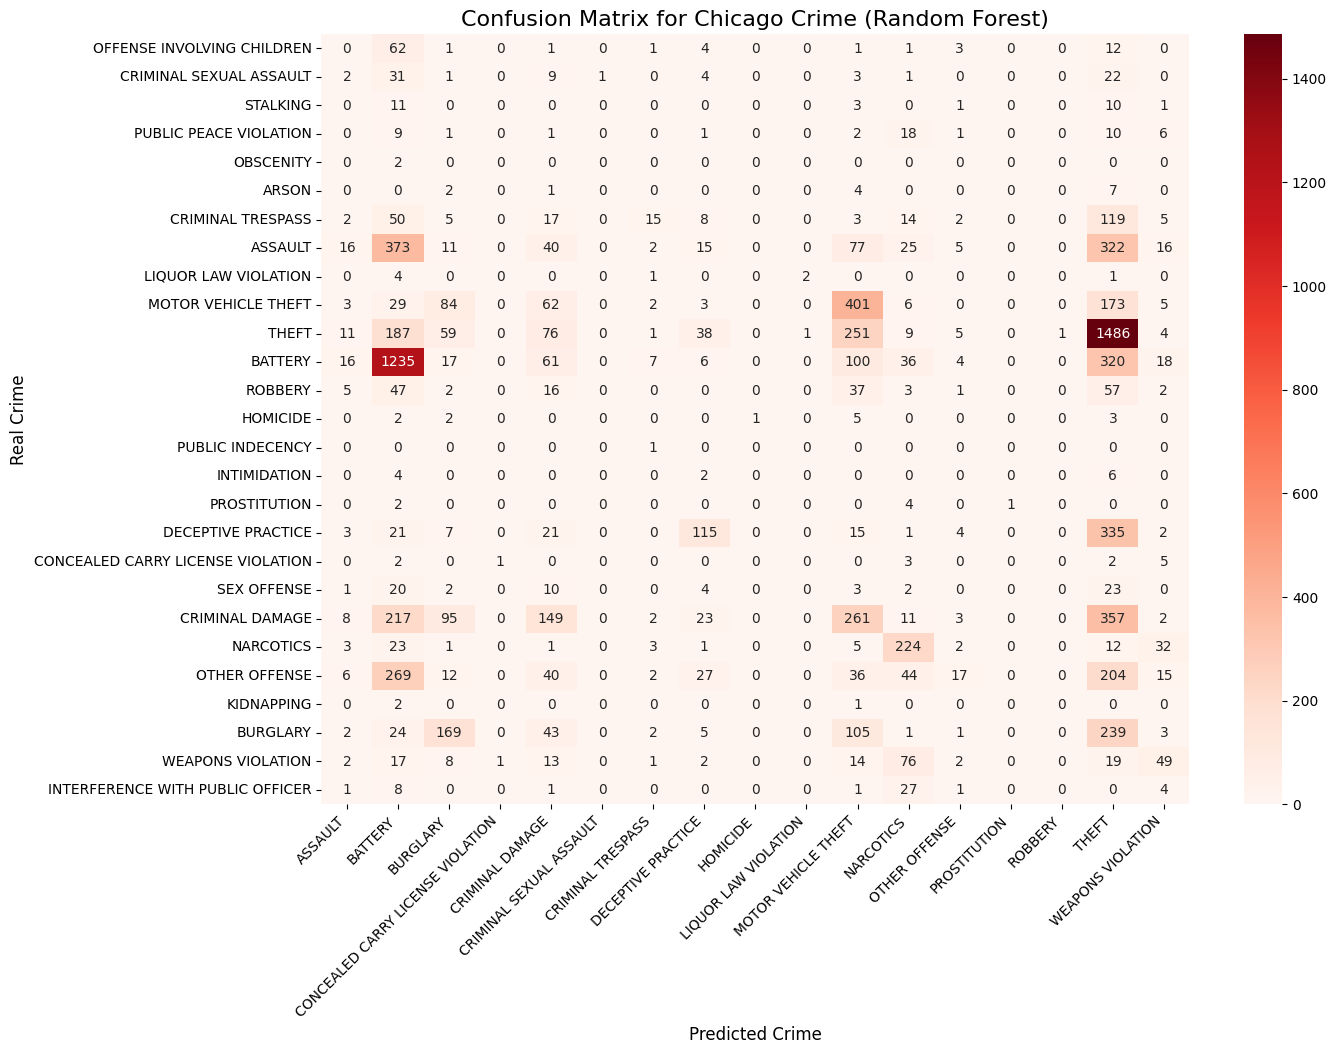

In [ ]:
matrix_crime = semi_matrix_mlpc.toPandas()
matrix_crime.set_index('primary_type', inplace=True)

plt.figure(figsize=(14, 10))
sns.heatmap(matrix_crime, annot=True, fmt='g', cmap='Reds')

plt.title('Confusion Matrix for Chicago Crime (Random Forest)', fontsize=16)
plt.ylabel("Real Crime", fontsize=12)
plt.xlabel("Predicted Crime", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.show()


## Wnioski
Podsumowanie kroku 5.

1. **Niestabilność klas:** jest to główny problem który zauważyłem w próbach tworzenia modeli uczenia maszynowego. Jak jesteśmy w stanie zauważyć z zadania 4 dwa najczęściej występujące przewinienia to: **THEFT** i **BATTERY**. Jest ich znacznie więcej niż jakichkolwiek innych przewinień, co doprowadza do tego że modele będą "zakładać" te 2 warianty gdy nie będą pewne co to za przestępstwo. Aby to poprawić należałoby zastosowanie technik balansowania zbioru.
2. **Niskie Acc w obu przypadkach:** Dla drzewa decyzyjnego wskaźnik Accuracy wynosi: 39% a dla MLPC: 21% ( z zastosowaniem scalingu) dodam że przed zastosowaniem go Acc dla MLPC wynosiło około 29%. Aby lepiej zbadać wyniki należałoby zastosować: Precision, Recall i F1-Score dla każdej z klas.
3. **Porównanie Algorytmów**: W tego typu danych algorytm RF wygrywa znacznie nad MLPC. Wielowarstwowa sieć neuronowa gorzej radzi sobie z danymi tabelarycznymi w porównaniu do RF, szczególnie gdy występują spore różnice między danymi np 0.0 - 1.0(bool) a 41.8 (dla szerokości geograficznej). Wychodzi też zasada "No Free Lunch Theorem" która twierdzi że nie każdy algorytm uczenia maszynowego jest uniwersalny.
4. **Feature  Importance:** najważniejsze parametry dla Lasu Losowego to `location_index` i `domestic_index` a zaraz po nich `latitude` i `longitude`. Parametry takie jak: `pora_dnia_index`,`arrest_index` nie były tak wpływowe. Mówi nam to że model bardzo uważnie patrzył w jakich regionach odbywały się przestępstwa i czy występowała przemoc domowa.
